# Reading raw SmartSolo DLD files directly

`lib/smartsolo_dld.py` reads the node's own `seisNNN{X,Y,Z}.DLD` files – no SoloLite export needed – and plugs them into the location/selection/extraction tools, which write MiniSEED, SEG-Y and StationXML. Format notes: [`docs/DLD_FORMAT.md`](../docs/DLD_FORMAT.md); what was learned along the way: [`docs/FINDINGS.md`](../docs/FINDINGS.md).

Data: the six UTAS nodes of the Land Cruiser break test in `data/break_test/` (stored with Git LFS – run `git lfs pull` after cloning). See `break_test.ipynb` for the science.

In [1]:
import sys; sys.path.insert(0, "../lib")
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from obspy import UTCDateTime, read
import smartsolo_dld as dld, smartsolo_locate as loc, smartsolo_waveforms as wf
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
BT = Path("../data/break_test")
dld_files = sorted(BT.rglob("*.DLD")); [str(f.relative_to(BT)) for f in dld_files][:6]

['453004362/20230407040654/seis000X.DLD',
 '453004362/20230407040654/seis000Y.DLD',
 '453004362/20230407040654/seis000Z.DLD',
 '453009194/20230407041120/seis000X.DLD',
 '453009194/20230407041120/seis000Y.DLD',
 '453009194/20230407041120/seis000Z.DLD']

## 1. File header
Serial, firmware, start/end, position, script – so files can be identified even if renamed or mixed up. Note: the header position is the position **when the file was closed** (453010047 had already been picked up and carried ~180 m when seis000 was closed); use the tag positions instead.

In [2]:
hdr = pd.DataFrame([dld.read_dld_header(f) for f in dld_files if f.stem.endswith("Z")])
hdr[["serial", "file_index", "firmware", "project_name", "start", "end", "duration_s", "latitude", "longitude", "altitude", "leap_seconds", "file_size"]]

,serial,file_index,firmware,project_name,start,end,duration_s,latitude,longitude,altitude,leap_seconds,file_size
0,453004362,0,V1.0.5.6kp,UTASTesting,2023-03-31 01:29:23+00:00,2023-03-31 02:00:09+00:00,1846.0,-42.903853,147.327917,50.700001,0,2839040
1,453009194,0,V1.0.5.6kp,UTASTesting,2023-03-31 01:30:55+00:00,2023-03-31 01:59:17+00:00,1702.0,-42.903794,147.327997,60.200001,0,2617856
2,453010029,0,V1.0.5.6kp,UTASTesting,2023-03-31 01:32:19+00:00,2023-03-31 01:59:05+00:00,1606.0,-42.903789,147.327865,46.200001,0,2470400
3,453010047,0,V1.0.5.6kp,UTASTesting,2023-03-31 01:28:23+00:00,2023-03-31 01:59:09+00:00,1846.0,-42.903873,147.327797,40.599998,0,2839040
4,453010077,0,V1.0.5.6kp,UTASTesting,2023-03-31 01:33:25+00:00,2023-03-31 02:00:11+00:00,1606.0,-42.902253,147.329660,24.799999,0,2470400
5,453010167,0,V1.0.5.6kp,UTASTesting,2023-03-31 01:34:41+00:00,2023-03-31 01:58:39+00:00,1438.0,-42.902262,147.329663,28.900000,0,2212352


## 2. Time tags
After every 1000 samples: a 72-byte tag with a ms tick, the UTC time as text, GPS position, GPS time of week (TOW) and two counters. The tick step gives the sample rate: 2000 ms per 1000 samples → 500 sps.

In [3]:
f = next((BT / "453009194").glob("*/seis000Z.DLD"))
tags = dld.read_dld_tags(f)
print(len(tags), "tags; tick steps:", tags.tick_ms.diff().value_counts().to_dict())
tags.iloc[[0, 1, 2, 400, -1]][["block", "tick_ms", "time_label", "time_tow", "label_minus_tow_s", "phase_error", "counter", "latitude", "longitude"]]

852 tags; tick steps: {2000.0: 851}


,block,tick_ms,time_label,time_tow,label_minus_tow_s,phase_error,counter,latitude,longitude
0,0,9685588724480,2023-03-31 01:30:55+00:00,2023-03-31 01:30:53+00:00,2.0,0,0,-42.902450,147.329321
1,1,9685588726480,2023-03-31 01:30:57+00:00,2023-03-31 01:30:55+00:00,2.0,0,0,-42.902451,147.329320
2,2,9685588728480,2023-03-31 01:30:59+00:00,2023-03-31 01:30:57+00:00,2.0,0,0,-42.902451,147.329321
400,400,9685589524480,2023-03-31 01:44:15+00:00,2023-03-31 01:44:13+00:00,2.0,0,18400,-42.902465,147.329306
851,851,9685590426480,2023-03-31 01:59:17+00:00,2023-03-31 01:59:15+00:00,2.0,0,51000,-42.902437,147.329333


### Which time to trust: text label or GPS time of week?
In all six files the text label is exactly **2 s ahead** of the UTC computed from the GPS time of week (TOW), and the header field `leap_seconds` is 0. Files written after the receiver has learned the GPS–UTC offset have `leap_seconds = 18` and labels that agree with TOW; files that span that moment show the labels jumping back 2 s mid-file – see the excerpt in `data/timing_example/` below. Interpretation: until the almanac delivers the leap seconds the receiver uses an old default (16 s instead of 18), so labels are 2 s late; TOW (time of the *next* pulse, hence −1 s) is unaffected. Mixing nodes with corrected and uncorrected labels gives false 2-s offsets, so `time_source="tow"` is the default.

Check with real data: 453004362 stands 5 m from 453009194, and 453010077 12 m from 453010167. Cross-correlating 30-s windows with TOW times gives a median lag of a few ms; single windows scatter by up to ±1 s because the sources (cars) move, but there is no constant offset.

   serial  leap_seconds label_minus_tow
453004362             0           [2.0]
453009194             0           [2.0]
453010029             0           [2.0]
453010047             0           [2.0]
453010077             0           [2.0]
453010167             0           [2.0]


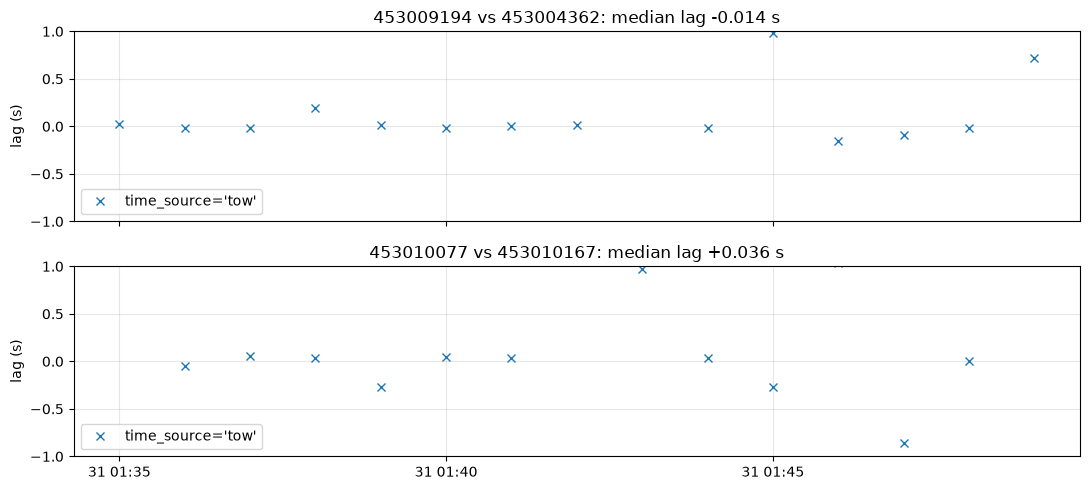

In [4]:
print(pd.DataFrame([dict(serial=p.parts[-3], leap_seconds=dld.read_dld_header(p)["leap_seconds"],
                         label_minus_tow=dld.read_dld_tags(p).label_minus_tow_s.unique().tolist())
                    for p in sorted(BT.glob("*/*/seis000Z.DLD"))]).to_string(index=False))

from obspy.signal.cross_correlation import correlate, xcorr_max
def lag_series(a, b, src="tow", t0="2023-03-31T01:35", t1="2023-03-31T01:50", win=30, step=60):
    fa = next((BT / a).glob("*/seis000Z.DLD")); fb = next((BT / b).glob("*/seis000Z.DLD"))
    out, t = [], UTCDateTime(t0)
    while t < UTCDateTime(t1):
        x = dld.read_dld(fa, starttime=t, endtime=t + win, time_source=src)
        y = dld.read_dld(fb, starttime=t, endtime=t + win, time_source=src)
        x.merge(fill_value=0); y.merge(fill_value=0); x, y = x[0], y[0]
        for tr in (x, y): tr.detrend("demean"); tr.filter("bandpass", freqmin=2, freqmax=40)
        n = min(x.stats.npts, y.stats.npts)
        lag, cc = xcorr_max(correlate(x.data[:n], y.data[:n], 1500), abs_max=False)
        out.append((t.datetime, lag / 500, cc)); t += step
    return pd.DataFrame(out, columns=["time", "lag_s", "cc"]).set_index("time")

pairs = [("453009194", "453004362"), ("453010077", "453010167")]
fig, axes = plt.subplots(len(pairs), 1, figsize=(11, 5), sharex=True)
for ax, (a, b) in zip(axes, pairs):
    s = lag_series(a, b); s = s[s.cc > 0.05]
    ax.plot(s.index, s.lag_s, "x", label="time_source='tow'")
    ax.set(ylabel="lag (s)", title=f"{a} vs {b}: median lag {s.lag_s.median():+.3f} s", ylim=(-1, 1)); ax.grid(alpha=.3); ax.legend(loc="lower left")
plt.tight_layout()

### The 2-s jump in real data
`data/timing_example/` holds two 3-minute excerpts from a later recording of 453009194 and 453010047 (7 April 2023, 21 m apart). The labels of 453009194 jump back 2 s at 00:58:37 (the label repeats); those of 453010047 were already corrected. With label times, `scan_dld` splits the file into two overlapping segments and the two nodes appear 2 s apart before the jump; with TOW times there is one segment and no offset.

In [5]:
EX = Path("../data/timing_example")
f94, f47 = EX / "453009194_seis001Z_excerpt.DLD", EX / "453010047_seis001Z_excerpt.DLD"
t94 = dld.read_dld_tags(f94)
print(t94.iloc[43:48][["block", "time_label", "time_tow", "label_minus_tow_s"]].to_string())
for src in ("label", "tow"):
    print(src, [(str(s["starttime"])[11:19], str(s["endtime"])[11:19]) for s in dld.scan_dld(f94, time_source=src)])
for a, b in [("00:57:20", "00:58:20"), ("00:59:00", "01:00:00")]:
    for src in ("label", "tow"):
        x, y = (dld.read_dld(f, starttime=UTCDateTime(f"2023-04-07T{a}"), endtime=UTCDateTime(f"2023-04-07T{b}"),
                             time_source=src).merge(fill_value=0)[0] for f in (f94, f47))
        for tr in (x, y): tr.detrend("demean"); tr.filter("bandpass", freqmin=2, freqmax=40)
        n = min(x.stats.npts, y.stats.npts)
        lag, cc = xcorr_max(correlate(x.data[:n], y.data[:n], 1500), abs_max=False)
        print(f"{a}-{b}  {src:5s}  lag {lag / 500:+.3f} s  cc {cc:.2f}")

    block                time_label                  time_tow  label_minus_tow_s
43     43 2023-04-07 00:58:35+00:00 2023-04-07 00:58:33+00:00                2.0
44     44 2023-04-07 00:58:37+00:00 2023-04-07 00:58:35+00:00                2.0
45     45 2023-04-07 00:58:37+00:00 2023-04-07 00:58:37+00:00                0.0
46     46 2023-04-07 00:58:39+00:00 2023-04-07 00:58:39+00:00                0.0
47     47 2023-04-07 00:58:41+00:00 2023-04-07 00:58:41+00:00                0.0
label [('00:57:09', '00:58:38'), ('00:58:37', '01:00:06')]
tow [('00:57:07', '01:00:06')]
00:57:20-00:58:20  label  lag +1.990 s  cc 0.27
00:57:20-00:58:20  tow    lag -0.010 s  cc 0.27
00:59:00-01:00:00  label  lag -0.008 s  cc 0.24
00:59:00-01:00:00  tow    lag -0.008 s  cc 0.24


## 3. Read samples

3 Trace(s) in Stream:
.10077..X | 2023-03-31T01:33:23.000000Z - 2023-03-31T02:00:10.998000Z | 500.0 Hz, 804000 samples
.10077..Y | 2023-03-31T01:33:23.000000Z - 2023-03-31T02:00:10.998000Z | 500.0 Hz, 804000 samples
.10077..Z | 2023-03-31T01:33:23.000000Z - 2023-03-31T02:00:10.998000Z | 500.0 Hz, 804000 samples


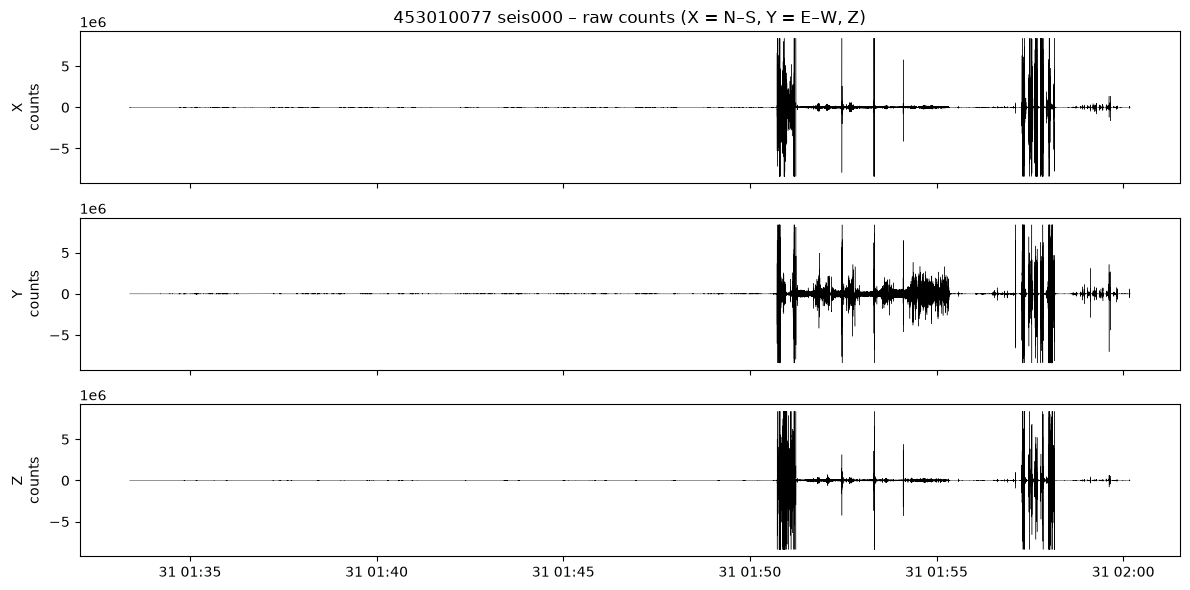

In [6]:
st = dld.read_dld_node(sorted((BT / "453010077").glob("*/seis000?.DLD")))
print(st)
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for a, tr in zip(axes, st):
    a.plot(tr.times("matplotlib"), tr.data, lw=.3, color="k"); a.set_ylabel(f"{tr.stats.channel}\ncounts")
axes[0].set_title("453010077 seis000 – raw counts (X = N–S, Y = E–W, Z)"); axes[-1].xaxis_date(); plt.tight_layout()

Samples run on smoothly across the 72-byte tags:

In [7]:
tr = st.select(channel="Z")[0]
d = np.abs(np.diff(tr.data.astype(float)))
print("median |Δ| at block boundaries:", np.median(d[999::1000]), " elsewhere:", np.median(d))

median |Δ| at block boundaries: 110.0  elsewhere: 107.0


## 4. Deployments from logs and DLD, select, cut, write MiniSEED / SEG-Y / StationXML

In [8]:
deps = loc.combine_deployments(loc.build_deployments(BT), loc.build_deployments_from_dld(BT))
deps[["deployment_id", "source", "start", "end", "latitude", "longitude", "sample_rate_hz", "channel_1_gain"]]

,deployment_id,source,start,end,latitude,longitude,sample_rate_hz,channel_1_gain
0,453004362_002,log,2023-03-31 01:29:21+00:00,2023-03-31 02:00:08.998000+00:00,-42.902513,147.329293,500.0,0.0
1,453004362_003,log,2023-04-06 23:46:33+00:00,2023-04-07 04:06:55+00:00,-42.866652,147.322338,500.0,0.0
2,453009194_002,log,2023-03-31 01:30:53+00:00,2023-03-31 01:59:16.998000+00:00,-42.902456,147.329333,500.0,0.0
3,453009194_003,log,2023-04-06 23:45:47+00:00,2023-04-07 04:08:57+00:00,-42.866477,147.322654,500.0,0.0
4,453010029_004,log,2023-03-31 01:32:17+00:00,2023-03-31 01:59:04.998000+00:00,-42.902213,147.329652,500.0,0.0
5,453010029_005,log,2023-04-06 23:46:23+00:00,2023-04-07 04:06:21+00:00,-42.866556,147.322508,500.0,0.0
6,453010047_002,log,2023-03-31 01:28:21+00:00,2023-03-31 01:59:08.998000+00:00,-42.902653,147.329122,500.0,0.0
7,453010047_003,log,2023-04-06 23:47:17+00:00,2023-04-07 04:10:03+00:00,-42.866343,147.322560,500.0,0.0
8,453010077_002,log,2023-03-31 01:33:23+00:00,2023-03-31 02:00:10.998000+00:00,-42.901756,147.330097,500.0,0.0
9,453010077_003,log,2023-04-06 23:45:39+00:00,2023-04-07 04:01:37+00:00,-42.866594,147.322763,500.0,0.0


In [9]:
index = wf.index_waveforms(BT)
sel = loc.select_deployments(deps, point=(-42.9017, 147.3301), radius_km=0.03,
                             start="2023-03-31T01:40:30", end="2023-03-31T01:41:30")
out = Path("../output/dld_demo")
st_m = wf.extract_waveforms(sel, index, out_dir=out / "mseed", out_format="MSEED")
st_s = wf.extract_waveforms(sel, index, out_dir=out / "segy", out_format="SEGY")
inv = wf.build_inventory(sel, stream=st_m, response="auspass"); inv.write(str(out / "stations.xml"), format="STATIONXML")
print(st_m); print(sorted(str(p.relative_to(out)) for p in out.rglob("*") if p.is_file()))

6 Trace(s) in Stream:
XX.10077..DPE | 2023-03-31T01:40:30.000000Z - 2023-03-31T01:41:29.998000Z | 500.0 Hz, 30000 samples
XX.10077..DPN | 2023-03-31T01:40:30.000000Z - 2023-03-31T01:41:29.998000Z | 500.0 Hz, 30000 samples
XX.10077..DPZ | 2023-03-31T01:40:30.000000Z - 2023-03-31T01:41:29.998000Z | 500.0 Hz, 30000 samples
XX.10167..DPE | 2023-03-31T01:40:30.000000Z - 2023-03-31T01:41:29.998000Z | 500.0 Hz, 30000 samples
XX.10167..DPN | 2023-03-31T01:40:30.000000Z - 2023-03-31T01:41:29.998000Z | 500.0 Hz, 30000 samples
XX.10167..DPZ | 2023-03-31T01:40:30.000000Z - 2023-03-31T01:41:29.998000Z | 500.0 Hz, 30000 samples
['mseed/XX/10077/XX.10077..DPE__20230331T014030Z__20230331T014130Z.mseed', 'mseed/XX/10077/XX.10077..DPN__20230331T014030Z__20230331T014130Z.mseed', 'mseed/XX/10077/XX.10077..DPZ__20230331T014030Z__20230331T014130Z.mseed', 'mseed/XX/10167/XX.10167..DPE__20230331T014030Z__20230331T014130Z.mseed', 'mseed/XX/10167/XX.10167..DPN__20230331T014030Z__20230331T014130Z.mseed', 'mseed/

In [10]:
raw = dld.read_dld(next((BT / "453010077").glob("*/seis000Z.DLD")), starttime="2023-03-31T01:40:30", endtime="2023-03-31T01:41:29.998")[0]
m = read(str(next((out / "mseed").rglob("*10077..DPZ*"))))[0]; s = read(str(next((out / "segy").rglob("*10077..DPZ*"))), format="SEGY")[0]
print(m.stats.starttime, s.stats.starttime, raw.stats.starttime)
print("MiniSEED == -DLD:", np.array_equal(m.data, -raw.data), "  SEG-Y == MiniSEED:", np.array_equal(s.data, m.data))

2023-03-31T01:40:30.000000Z 2023-03-31T01:40:30.000000Z 2023-03-31T01:40:30.000000Z
MiniSEED == -DLD: True   SEG-Y == MiniSEED: True


## 5. One call for a whole drive
```python
sel, inv, files = wf.convert_dld('/media/drive', out_dir='out', log_root='/media/drive', out_format='MSEED', chunk='1D')
```
Not run here to keep the repository output small (it would convert all ~45 MB).